# Lab 2: Python Script

### Benjamin Wilson

In [6]:
import pandas as pd
print(pd.__version__)

3.0.5


##### This was a transformation of the original suggested code to check the pandas version. I noticed this code block was taking a very long time to load with my virtual environment. I used the hds-computing virtual environment, but I executed the codeblock while my VS Code was still connecting to the kernel. I used ChatGPT-4o-mini to assist me in constructing a new virtual environment built off of the arm64 infrastructure, and then tested pandas within the first codeblock.

In [7]:
url = ("https://www.ncbi.nlm.nih.gov/geo/download/"
       "?acc=GSE52778&format=file&file=GSE52778_All_Sample_FPKM_Matrix.txt.gz")
fpkm = pd.read_csv(url, sep=r"\s+", compression="gzip")

##### I used the source.md file listed in the Lab 2 section to create the FPKM expression matrix. However, when doing some of the downstream analysis, an error popped up entitled "KeyError: 'Dex_FPKM' The above exception was the direct cause of the following exception: KeyError Traceback (most recent call last) Cell In[6], line 2". I used GPT-4o-mini to help explain the issue, and it told me that the issue was the FPKM separator parameter. The new separator recommended allowed the header to be split into the requisite columns.

In [8]:
print(fpkm.shape)
print(fpkm.columns.tolist())

(23273, 41)
['gene_id', 'tracking_id', 'class_code', 'nearest_ref_id', 'gene_short_name', 'tss_id', 'locus', 'length', 'coverage', 'Dex_FPKM', 'Dex_conf_lo', 'Dex_conf_hi', 'Dex_status', 'Alb_FPKM', 'Alb_conf_lo', 'Alb_conf_hi', 'Alb_status', 'Untreated_FPKM', 'Untreated_conf_lo', 'Untreated_conf_hi', 'Untreated_status', 'Alb_Dex_FPKM', 'Alb_Dex_conf_lo', 'Alb_Dex_conf_hi', 'Alb_Dex_status', 'Dex_LL14', 'Dex_LL06', 'Dex_LL02', 'Dex_LL10', 'Alb_LL07', 'Alb_LL03', 'Alb_LL11', 'Alb_LL15', 'Untreated_LL09', 'Untreated_LL05', 'Untreated_LL13', 'Untreated_LL01', 'Alb_Dex_LL08', 'Alb_Dex_LL04', 'Alb_Dex_LL12', 'Alb_Dex_LL16']


##### This was a quality control check to understand the data I was working with. The first function displays the shape (rows, columns) of the dataset, and the second lists all of the columns.

In [9]:
top_genes = fpkm.nlargest(10, "Dex_FPKM")

top_genes[["gene_short_name", "Dex_FPKM"]]

,gene_short_name,Dex_FPKM
12739,MIR4461,56556.90
12362,MIR3064,13168.10
6777,FTL,9931.95
19361,SNORD29,9667.82
19430,SNORD80,9667.62
6774,FTH1,6928.97
13012,MIR5047,5774.09
12333,MIR24-1,5435.69
21213,TPT1,4573.97
19391,SNORD5,3812.50


##### I wanted to find the top 10 genes expressed in the FPKM expression matrix. I did this by finding the largest values in Dex_FPKM, and then assigned it to each respective short name. This produced the table shown above.

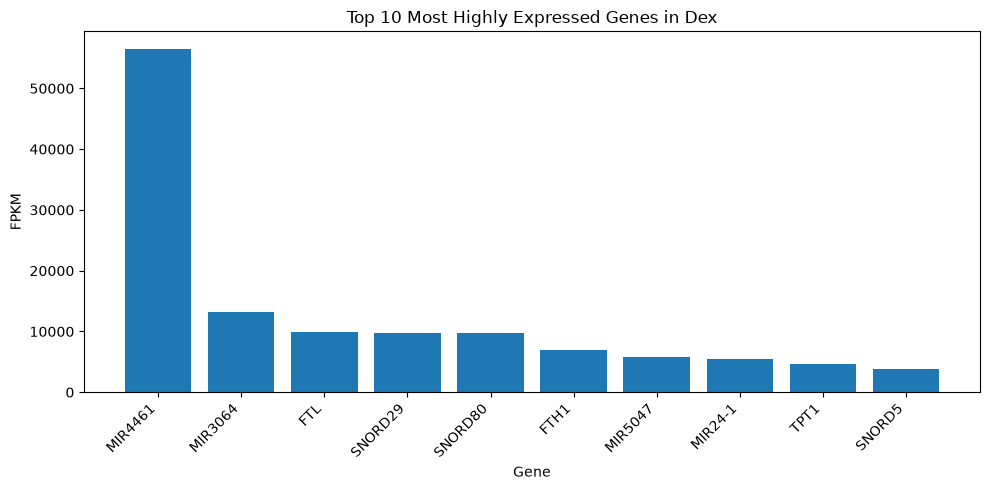

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(top_genes["gene_short_name"], top_genes["Dex_FPKM"])

plt.xlabel("Gene")
plt.ylabel("FPKM")
plt.title("Top 10 Most Highly Expressed Genes in Dex")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

##### I was a bit unfamiliar with matplotlib, so I asked GPT-4o-mini to assist me in tweaking some features shown above. I wanted to make a visualization of the work I did above: a bar chart of the most highly expressed genes in Dex. This visualization used the top_genes table, assigning gene to the x-axis and Dex_FPKM to the y-axis. After assinging labels and a title, the final functions improve legibility by rotating the x-axis labels to be sure they are not cut off.